# Логистическая регрессия
## Цель работы
Познакомиться с широко используемым методом бинарной классификации - логистической регрессией.

## Содержание работы
- Сгенерировать матрицу признаков и вектор целей для задачи классификации с использованием make_classification из библиотеки sklearn.datasets. Число классов возьмите равным двум.
- Реализовать модель логистической регрессии методом градиентного спуска, не используя библиотечные функции.
- Оценить качество построенной модели, используя метрики accuracy и F1-score.
- Реализовать модель логистической регрессии LogisticRegression из библиотеки sklearn.linear_model и оценить качество построенной модели, используя метрики accuracy и F1-score.
- Сравнить результаты двух реализаций.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Сгенерируем матрицу признаков и вектор целей для задачи классификации. Для этого воспользуемся библиотечной функцией make_classification, которая генерирует случайное распределение по заданным параметрам. Число генерируемых точек данных задачим равным 1000, количество признаков - 2 для того, чтобы их можно было изобразить на графике. Оба признака будут информативными, то есть влиять на значение целевой переменной. Классов у нас тоже будет два, то есть будем решать задачу бинарной классификации. Параметр class_sep задает расстояние (зазор) между классами.

In [19]:
from sklearn.datasets import make_classification
X,y = make_classification (n_samples=1000,
                          n_features=2,
                          n_informative=2,
                          n_redundant=0,
                          n_classes=2,
                          class_sep=2,
                          random_state=1)

In [20]:
pd.DataFrame(X).head()

,0,1
0,1.863411,0.087646
1,-1.530997,1.901182
2,-0.017224,-2.591112
3,-2.032039,-1.801162
4,4.620555,0.901124


Анализировать такие данные в табличном виде не очень наглядно, поэтому построим их визуальное распределение. Обратите внимание, как в данном примере используется условная индексация одного массива (признаков) другим массивом (целевой переменной):

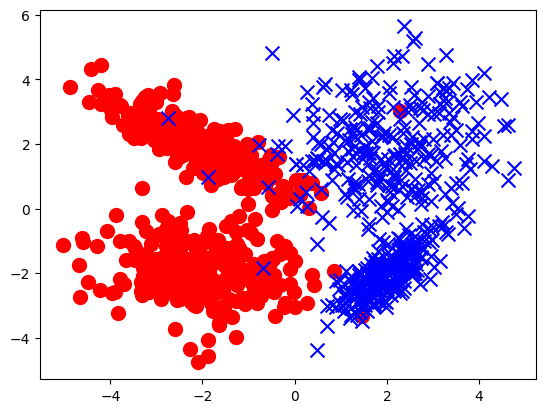

In [21]:
plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)
plt.show()

In [22]:
class SGD():
    def __init__(self, alpha=0.5, n_iters=1000):
        self.b = None
        self._alpha = alpha
        self._n_iters = n_iters
    
    def gradient_step(self, b, b_grad):
        return b - self._alpha * b_grad

    def grad_func(self):
        raise Exception("not implemented yet")
        
    def optimize(self, X, y, start_b, n_iters):
        b = start_b.copy()
        for i in range(n_iters):
            b_grad = self.grad_func(X, y, b)
            b = self.gradient_step(b, b_grad)
        return b

    def fit(self, X, y):
        m = X.shape[1]
        start_b = np.ones(m)
        self.b = self.optimize(X, y, start_b, self._n_iters)

        return self.b

Обратите внимание, что в этом классе мы не реализовали использованный в одном месте метод grad_func(X, y, b). Этот метод моделеспецифичный, поэтому определим его во втором классе. Такая архитектура, в частности, означает, что наш класс SGD не можут использоваться сам по себе - он абстрактный. В конкретной реализации этого класса должен быть определен этот метод.

Создадим класс, реализующего логистическую регрессию. Конструктор здесь нам не нужен, так как он будет наследоваться. А начнем непосредственно с функции гипотезы:

In [23]:
class LogReg(SGD):
    def sigmoid(self, X, b):        
        return 1. / (1. + np.exp(-X.dot(b)))

    def grad_func(self, X, y, b):
        n = X.shape[0]
        grad = 1. / n * X.transpose().dot(self.sigmoid(X, b) - y)
        return grad

    def predict_proba(self, X):
        return self.sigmoid(X, self.b)

    def predict(self, X):
        y_pred = self.predict_proba(X) > 0.5
        return y_pred

In [24]:
logreg = LogReg()
X = np.hstack([np.ones(X.shape[0])[:, np.newaxis], X])

In [25]:
logreg.fit(X, y)
y_pred = logreg.predict(X)

In [26]:
from sklearn.metrics import accuracy_score, f1_score
ac = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)
print(f'accuracy = {ac:.2f} F1-score = {f1:.2f}')

accuracy = 0.98 F1-score = 0.98


In [27]:
y_pred_proba = logreg.predict_proba(X)

После создания модели логистической регрессии логичным шагом будет вывести ее на график вместе с точками данных. Проблема в том, что это не так просто, как в случае с линейной регрессией, так как мы имеем два измерения признаков плюс еще значение самой функции модели. Для того, чтобы наглядно увидеть, как сочетается значение модели с точками воспользуемся построением контурного графика.

Для начала надо подготовить равномерные данные для рисования функции гипотезы. Нам понадобится создать двумерную сетку. К счастью, в numpy есть необходимые элементы. Подробный разбор кода выходит за рамки данного пособия, так как использует продвинутые возможности библиотеки numpy. Если вам интересно, как работает этот код, обратитесь к документации к используемым методам:

In [28]:
xx, yy = np.meshgrid(
    np.arange(X.min(axis=0)[1]-1, X.max(axis=0)[1]+1, 0.01), 
    np.arange(X.min(axis=0)[2]-1, X.max(axis=0)[2]+1, 0.01))
XX = np.array(list(zip(xx.ravel(), yy.ravel()))).reshape((-1, 2))
XX = np.array([(1, *xx) for xx in XX])

В данном коде мы создаем двумерную матрицу, содержащую все комбинации значений признаков в заданном диапазоне. Другими словами, мы создаем равномерную сетку в прямоугольнике от минимального до максимального значения каждого признака (отступая для красоты 1 в обоих направлениях). Попробуйте вывести получившиеся переменные, чтобы понять принцип построения данной сетки. А после мы используем матрицу XX как исходные данные для модели:

In [29]:
Z = logreg.predict_proba(XX)
Z = Z.reshape(xx.shape)

Данный код выполнит предсказание модели в каждой точке нашей сетки. Эти данные мы сможем использовать для того, чтобы построить контурный график вот так:

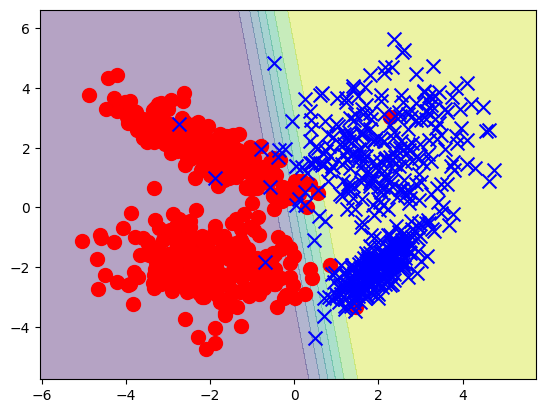

In [30]:
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X[:, 1][y==0], X[:, 2][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 1][y==1], X[:, 2][y==1], marker="x", c='b', s=100)

Сделайте вывод по данному графику. Насколько хорошая получилась модель для имеющихся данных?

Теперь проделаем то же самое, используя библиотечные функции.

Создадим экземпляр класса:

In [16]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X, y)
y_pred_lr = model.predict(X)
y_pred_lr[:10]

array([1, 0, 0, 0, 1, 1, 1, 0, 0, 0])

In [17]:
ac = accuracy_score(y, y_pred_lr)
f1 = f1_score(y, y_pred)
print(f'accuracy = {ac:.2f} F1-score = {f1:.2f}')

accuracy = 0.98 F1-score = 0.98
